In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings  # Added import for warnings module
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Replace deprecated plot_confusion_matrix with ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import metrics
%matplotlib inline
import os
warnings.filterwarnings("ignore")

In [3]:
def load_customers_data(data_path=r"C:\Users\nooth\Downloads"):
    csv_path = os.path.join(data_path,"Whosale customers data" )
    return pd.read_csv(csv_path)

In [4]:
df = pd.read_csv("C:/Users/nooth/Downloads/archive (8)/Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [6]:
df.describe()
df.shape

(440, 8)

In [7]:
df.drop(['Channel','Region',],axis=1,inplace=True)

In [8]:
df.head()


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [10]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

X_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


In [11]:
objective_function=[] 
for i in range(1,11):
    clustering=KMeans(n_clusters=i, init='k-means++')
    clustering.fit(X_scaled)
    objective_function.append(clustering.inertia_)
#inertia is calculaing min intra cluster distance
# objective function contains min intra cluster distances 
objective_function

  File "C:\Users\nooth\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\nooth\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\nooth\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nooth\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                     

[2639.999999999999,
 1992.7173914350146,
 1626.8315432835213,
 1326.2476040780139,
 1184.2341038780498,
 917.6581413399979,
 822.7248548197103,
 778.8261152289605,
 747.4573448383242,
 628.7920831068119]

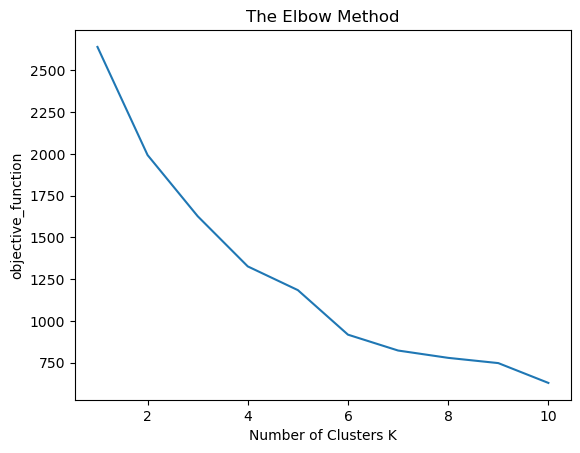

In [12]:
plt.plot(range(1,11),objective_function)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters K')
plt.ylabel('objective_function')
plt.show()


In [13]:
# Training the model with optimal no of clusters
clustering=KMeans(n_clusters=5,init='k-means++',random_state=0)
labels=clustering.fit_predict(X_scaled)
# x and y  coordinates of all clusters
# Centroids of clusters
clustering.cluster_centers_[:]

array([[ 1.65897027, -0.10837198, -0.21770307,  1.10347289, -0.40460199,
         0.33302495],
       [ 0.38872897,  3.94304862,  4.02164626,  0.03578413,  4.22611641,
         0.94163573],
       [-0.22836933, -0.38549965, -0.43882321, -0.16398421, -0.39956119,
        -0.19472509],
       [-0.51381889,  0.64560212,  0.8982647 , -0.34063818,  0.9066611 ,
         0.04754206],
       [ 1.96681731,  5.17550306,  1.28721685,  6.90059988, -0.55486198,
        16.47844745]])

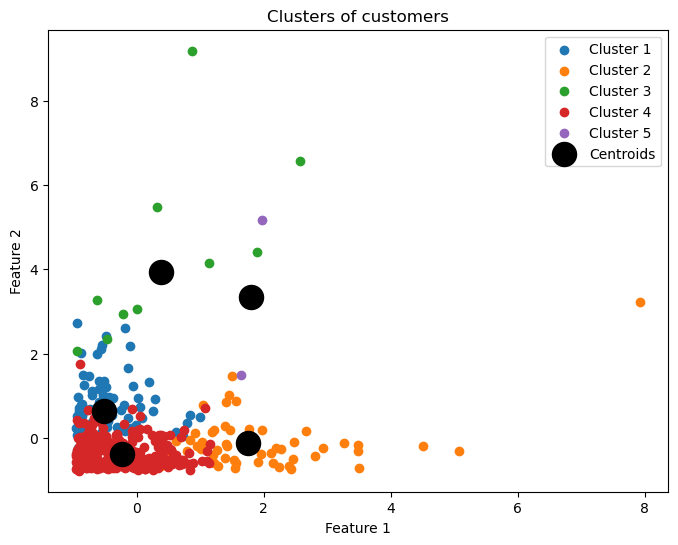

In [14]:
# Import necessary libraries
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

# Assuming X_scaled is your scaled data and labels are your cluster assignments
# If you don't have labels yet, you need to create them

# Create and fit the KMeans model
kmeans = KMeans(n_clusters=5, random_state=42)  # Create KMeans object
kmeans.fit(X_scaled)  # Fit the model to your data
labels = kmeans.labels_  # Get cluster labels
df['Cluster'] = labels
df.head()
# Now create the visualization
plt.figure(figsize=(8,6))

for i in range(5):
    plt.scatter(
        X_scaled.loc[labels==i, X_scaled.columns[0]],
        X_scaled.loc[labels==i, X_scaled.columns[1]],
        label=f'Cluster {i+1}'
    )

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300, c='black', label='Centroids'
)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clusters of customers')
plt.legend()
plt.show()

In [15]:
clustering.inertia_

1060.9989740147732

In [16]:
df['Cluster'] = labels
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,12669,9656,7561,214,2674,1338,3
1,7057,9810,9568,1762,3293,1776,0
2,6353,8808,7684,2405,3516,7844,0
3,13265,1196,4221,6404,507,1788,3
4,22615,5410,7198,3915,1777,5185,1


In [17]:

df.groupby('Cluster').mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,5509.250000,10555.635417,16477.927083,1420.125000,7199.406250,1658.791667
1,34188.627119,4850.576271,5870.000000,7215.559322,955.847458,2491.796610
2,16911.090909,34864.363636,46126.181818,3245.454545,23008.090909,4177.363636
3,9112.235294,2965.404412,3783.702206,2413.591912,976.908088,974.926471
4,34782.000000,30367.000000,16898.000000,48701.500000,755.500000,26776.000000


In [18]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.36890127429678043


In [18]:
df['Cluster'].value_counts()

Cluster
3    272
0     96
1     59
2     11
4      2
Name: count, dtype: int64